In [32]:
# Ruta correcta del proyecto

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Obtener la ruta del notebook actual
notebook_dir = os.getcwd()
print(f" Directorio actual del notebook: {notebook_dir}")

# Construir la ruta al archivo CSV
csv_path = os.path.join('..', 'data', 'processed', 'resenas_clean.csv')
csv_path = os.path.abspath(csv_path)

print(f"Ruta al archivo CSV: {csv_path}")

# Verificar si el archivo existe
if os.path.exists(csv_path):
    print("Archivo encontrado!")
else:
    print("Archivo no encontrado en la ruta esperada")
    print("\nBuscando en toda la estructura del proyecto...")

    # Buscar recursivamente
    for root, dirs, files in os.walk('..'):
        for file in files:
            if file == 'resenas_clean.csv':
                csv_path = os.path.join(root, file)
                print(f"Archivo encontrado en: {csv_path}")
                break
        else:
            continue
        break

 Directorio actual del notebook: C:\Reseñas_turisticas_CR\Rese-as-turisticas\notebooks
Ruta al archivo CSV: C:\Reseñas_turisticas_CR\Rese-as-turisticas\data\processed\resenas_clean.csv
Archivo encontrado!


In [33]:
# Carga del dataset

try:
    df = pd.read_csv(csv_path, encoding='utf-8')
    print("Datos cargados exitosamente!")
    print(f"Shape del dataset: {df.shape}")
    print(f"Columnas: {df.columns.tolist()}")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")
    # Intentar con otra codificación
    try:
        df = pd.read_csv(csv_path, encoding='latin1')
        print("Cargado con encoding 'latin1'")
    except:
        print("No se pudo cargar el archivo con ninguna codificación")

Datos cargados exitosamente!
Shape del dataset: (787, 7)
Columnas: ['reseña', 'calificación', 'tipo_lugar', 'fuente', 'nombre', 'fecha', 'grupo_de_viaje']


In [35]:
# Vista previa de los datos
print("Primeras 5 filas:")
df.head()

Primeras 5 filas:


,reseña,calificación,tipo_lugar,fuente,nombre,fecha,grupo_de_viaje
0,fue una pésima experiencia llegamos solo por u...,1,hotel,https://search.google.com/local/reviews?placei...,baldi hot springs hotel resort & spa,05/23/2026,NaN
1,todo muy bonito realmente me quedo sin palabra...,5,hotel,https://search.google.com/local/reviews?placei...,baldi hot springs hotel resort & spa,05/17/2026,NaN
2,una experiencia relajante e imperdible en cost...,5,hotel,https://search.google.com/local/reviews?placei...,baldi hot springs hotel resort & spa,05/16/2026,familia
3,buena experiencia nos habían recomendado en gr...,4,hotel,https://search.google.com/local/reviews?placei...,baldi hot springs hotel resort & spa,05/16/2026,pareja
4,un gran lugar para hospedarse un pasasar un ra...,5,hotel,https://search.google.com/local/reviews?placei...,baldi hot springs hotel resort & spa,05/15/2026,familia


In [36]:
print("Últimas 5 filas:")
df.tail()

Últimas 5 filas:


,reseña,calificación,tipo_lugar,fuente,nombre,fecha,grupo_de_viaje
782,las personas todas en general muy atentas los ...,5,hotel,https://search.google.com/local/reviews?placei...,the royal corin thermal water spa & resort,01/06/2024,NaN
783,solo pasamos por el day pass de las aguas term...,4,hotel,https://search.google.com/local/reviews?placei...,the springs resort & spa at arenal,05/01/2026,pareja
784,fuimos a las termas preciosas para disfrutar y...,4,hotel,https://search.google.com/local/reviews?placei...,the springs resort & spa at arenal,04/11/2026,familia
785,lugar muy acogedor lindas piscinas nos encantó,5,hotel,https://search.google.com/local/reviews?placei...,the springs resort & spa at arenal,04/07/2026,pareja
786,precioso lugar excelente servicio pero bastant...,4,hotel,https://search.google.com/local/reviews?placei...,the springs resort & spa at arenal,03/03/2026,NaN


In [37]:
# Información general del dataset

print("Información del dataset:")
print(f"Total de reseñas: {len(df)}")
print(f"Total de columnas: {len(df.columns)}")
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

Información del dataset:
Total de reseñas: 787
Total de columnas: 7

Tipos de datos:
reseña              str
calificación      int64
tipo_lugar          str
fuente              str
nombre              str
fecha               str
grupo_de_viaje      str
dtype: object

Valores nulos por columna:
reseña              0
calificación        0
tipo_lugar          0
fuente              0
nombre              0
fecha               0
grupo_de_viaje    676
dtype: int64


In [38]:
# Estadísticas descriptivas

print("Estadísticas de calificaciones:")
print(df['calificación'].describe())
print("\nDistribución de calificaciones:")
print(df['calificación'].value_counts().sort_index())

Estadísticas de calificaciones:
count    787.000000
mean       4.454892
std        1.102362
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: calificación, dtype: float64

Distribución de calificaciones:
calificación
1     38
2     36
3     44
4     81
5    588
Name: count, dtype: int64


In [40]:
# Limpieza y preprocesamiento

# Convertir fecha a datetime
df['fecha'] = pd.to_datetime(df['fecha'], format='%m/%d/%Y', errors='coerce')

# Crear columnas temporales
df['mes'] = df['fecha'].dt.month
df['año'] = df['fecha'].dt.year
df['mes_nombre'] = df['fecha'].dt.month_name()

# Limpiar tipo_lugar (corregir error de tipeo)
df['tipo_lugar'] = df['tipo_lugar'].replace('retaurante', 'restaurante')

# Crear columna de sentimiento
def sentimiento(calif):
    if calif >= 4:
        return 'Positivo'
    elif calif == 3:
        return 'Neutral'
    else:
        return 'Negativo'

df['sentimiento'] = df['calificación'].apply(sentimiento)

# Longitud de reseñas
df['longitud_resena'] = df['reseña'].str.len()

print("Preprocesamiento completado")
print(f"Nuevas columnas agregadas: mes, año, mes_nombre, sentimiento, longitud_resena")

Preprocesamiento completado
Nuevas columnas agregadas: mes, año, mes_nombre, sentimiento, longitud_resena


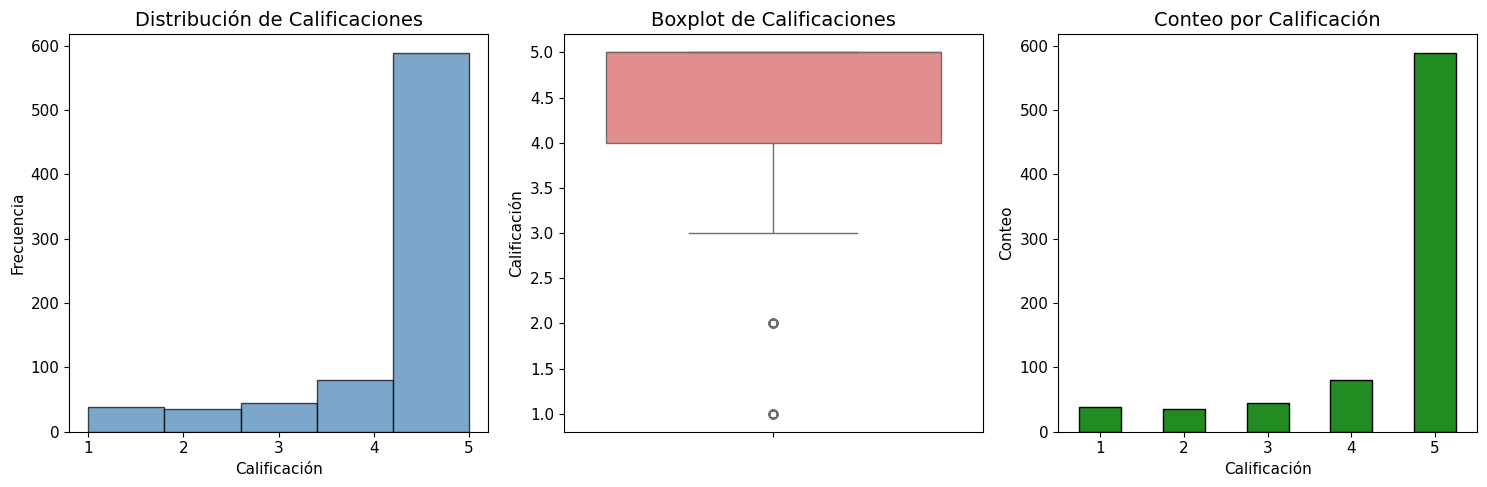


Porcentaje por calificación:
  1 estrella(s): 4.8%
  2 estrella(s): 4.6%
  3 estrella(s): 5.6%
  4 estrella(s): 10.3%
  5 estrella(s): 74.7%


In [42]:
# Visualización: Distribución de calificaciones

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histograma
axes[0].hist(df['calificación'], bins=5, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribución de Calificaciones', fontsize=14)
axes[0].set_xlabel('Calificación')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks([1,2,3,4,5])

# Boxplot
sns.boxplot(y=df['calificación'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot de Calificaciones', fontsize=14)
axes[1].set_ylabel('Calificación')

# Gráfico de barras
df['calificación'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='forestgreen', edgecolor='black')
axes[2].set_title('Conteo por Calificación', fontsize=14)
axes[2].set_xlabel('Calificación')
axes[2].set_ylabel('Conteo')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Porcentajes
print("\nPorcentaje por calificación:")
porcentajes = df['calificación'].value_counts(normalize=True).sort_index() * 100
for calif, pct in porcentajes.items():
    print(f"  {calif} estrella(s): {pct:.1f}%")

Estadísticas por tipo de lugar:
                 Promedio  Mediana  Conteo  Desv Estándar
tipo_lugar                                               
hotel                4.54      5.0     286           1.02
parque nacional      4.63      5.0     263           0.84
restaurante          4.16      5.0     238           1.37


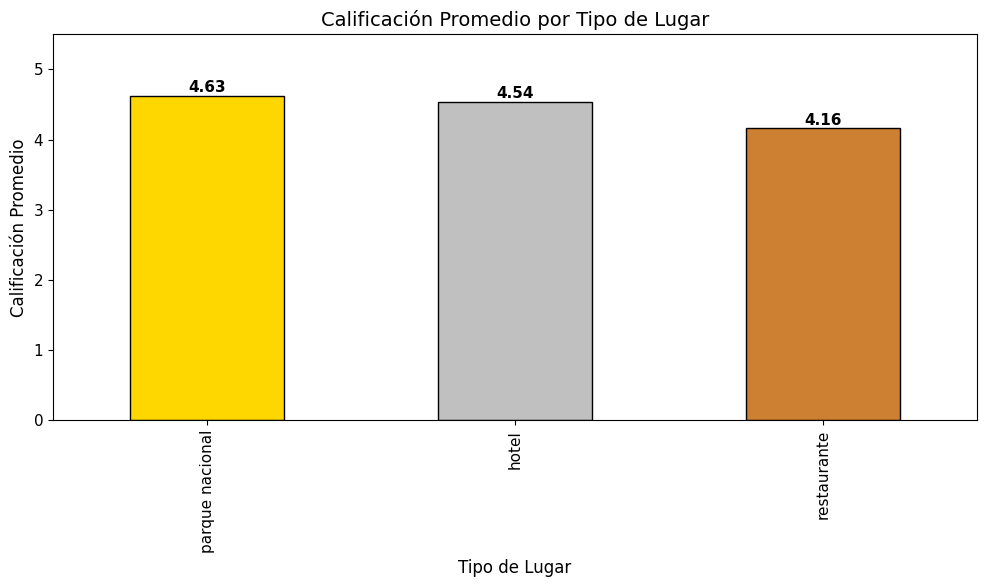

In [43]:
# Análisis por tipo de lugar

# Estadísticas por tipo
stats_tipo = df.groupby('tipo_lugar')['calificación'].agg(['mean', 'median', 'count', 'std']).round(2)
stats_tipo.columns = ['Promedio', 'Mediana', 'Conteo', 'Desv Estándar']
print("Estadísticas por tipo de lugar:")
print(stats_tipo)

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))
promedios = df.groupby('tipo_lugar')['calificación'].mean().sort_values(ascending=False)
colors = ['gold', 'silver', '#CD7F32']
promedios.plot(kind='bar', ax=ax, color=colors[:len(promedios)], edgecolor='black')

ax.set_title('Calificación Promedio por Tipo de Lugar', fontsize=14)
ax.set_xlabel('Tipo de Lugar', fontsize=12)
ax.set_ylabel('Calificación Promedio', fontsize=12)
ax.set_ylim(0, 5.5)
for i, v in enumerate(promedios):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Estadísticas de longitud de reseñas:
  Media: 217 caracteres
  Mediana: 121 caracteres
  Máxima: 3708 caracteres
  Mínima: 8 caracteres


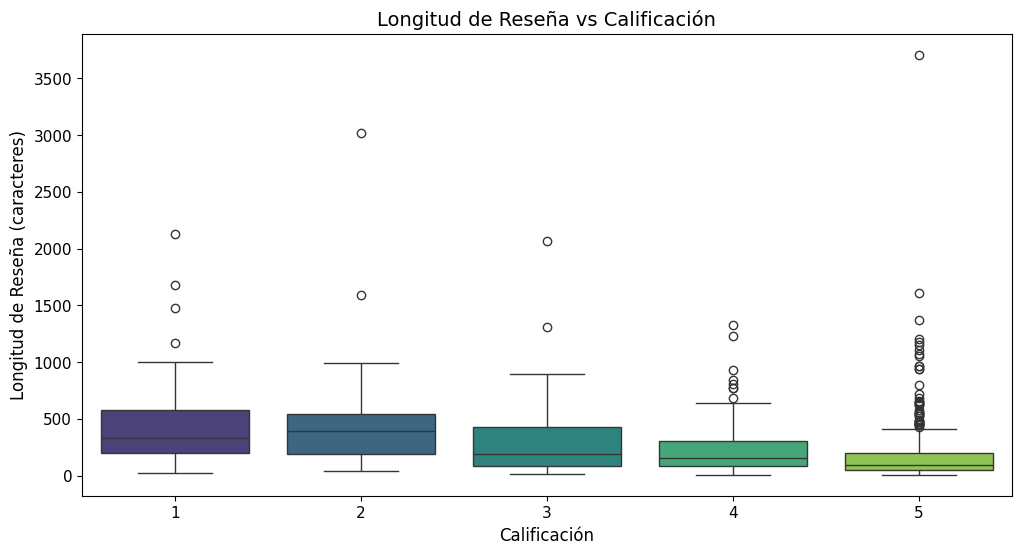

In [44]:
# Análisis de longitud de reseñas

print("Estadísticas de longitud de reseñas:")
print(f"  Media: {df['longitud_resena'].mean():.0f} caracteres")
print(f"  Mediana: {df['longitud_resena'].median():.0f} caracteres")
print(f"  Máxima: {df['longitud_resena'].max():.0f} caracteres")
print(f"  Mínima: {df['longitud_resena'].min():.0f} caracteres")

# Relación entre longitud y calificación
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='calificación', y='longitud_resena', palette='viridis', ax=ax)
ax.set_title('Longitud de Reseña vs Calificación', fontsize=14)
ax.set_xlabel('Calificación', fontsize=12)
ax.set_ylabel('Longitud de Reseña (caracteres)', fontsize=12)
plt.show()

Top 10 establecimientos con más reseñas:
nombre
barceló tambor                          76
restaurante silvestre                   54
la divina comida fusión peruana         42
parque nacional santa rosa              42
el novillo alegre sabana                40
baldi hot springs hotel resort & spa    39
poás volcano                            38
sikwa restaurante                       35
parque nacional volcán irazú            33
furca                                   28
Name: count, dtype: int64


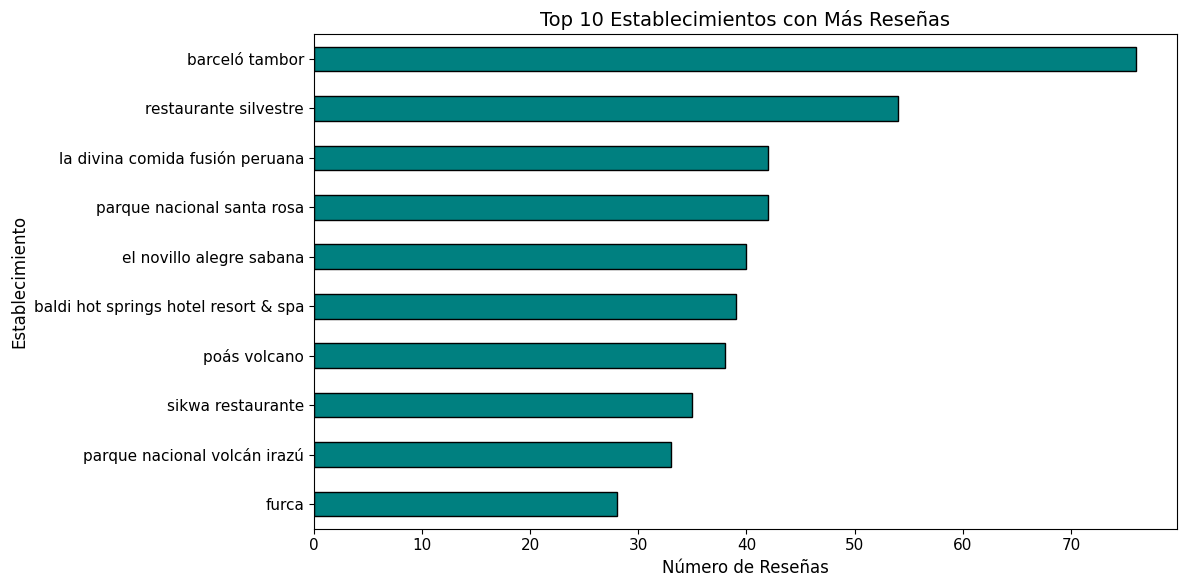

In [45]:
# Top establecimientos

# Top por número de reseñas
top_establecimientos = df['nombre'].value_counts().head(10)
print("Top 10 establecimientos con más reseñas:")
print(top_establecimientos)

# Gráfico
plt.figure(figsize=(12, 6))
top_establecimientos.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Establecimientos con Más Reseñas', fontsize=14)
plt.xlabel('Número de Reseñas', fontsize=12)
plt.ylabel('Establecimiento', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [46]:
# Top mejor calificados (mínimo 3 reseñas)
conteo_nombre = df.groupby('nombre').size()
nombres_filtrados = conteo_nombre[conteo_nombre >= 3].index
df_filtrado = df[df['nombre'].isin(nombres_filtrados)]

if len(df_filtrado) > 0:
    top_mejores = df_filtrado.groupby('nombre')['calificación'].mean().sort_values(ascending=False).head(10)
    print("Top 10 establecimientos mejor calificados (mínimo 3 reseñas):")
    for i, (nombre, calif) in enumerate(top_mejores.items(), 1):
        print(f"  {i}. {nombre}: {calif:.2f} ")
else:
    print("⚠No hay establecimientos con 3 o más reseñas")

Top 10 establecimientos mejor calificados (mínimo 3 reseñas):
  1. tabacón thermal resort and spa: 5.00 
  2. barceló tambor: 4.96 
  3. secrets papagayo costa rica: 4.93 
  4. nayara gardens hotel and spa: 4.92 
  5. parque nacional cahuita: 4.92 
  6. restaurante silvestre: 4.83 
  7. parque nacional marino ballena: 4.81 
  8. parque nacional tortuguero: 4.78 
  9. parque nacional rincón de la vieja: 4.75 
  10. costa rica marriott hotel hacienda belen: 4.73 


Distribución de grupos de viaje:
grupo_de_viaje
familia    44
pareja     33
amigos     23
solo       11
Name: count, dtype: int64

Calificación promedio por grupo de viaje:
                Promedio  Conteo
grupo_de_viaje                  
pareja              4.45      33
familia             4.43      44
solo                4.36      11
amigos              4.35      23


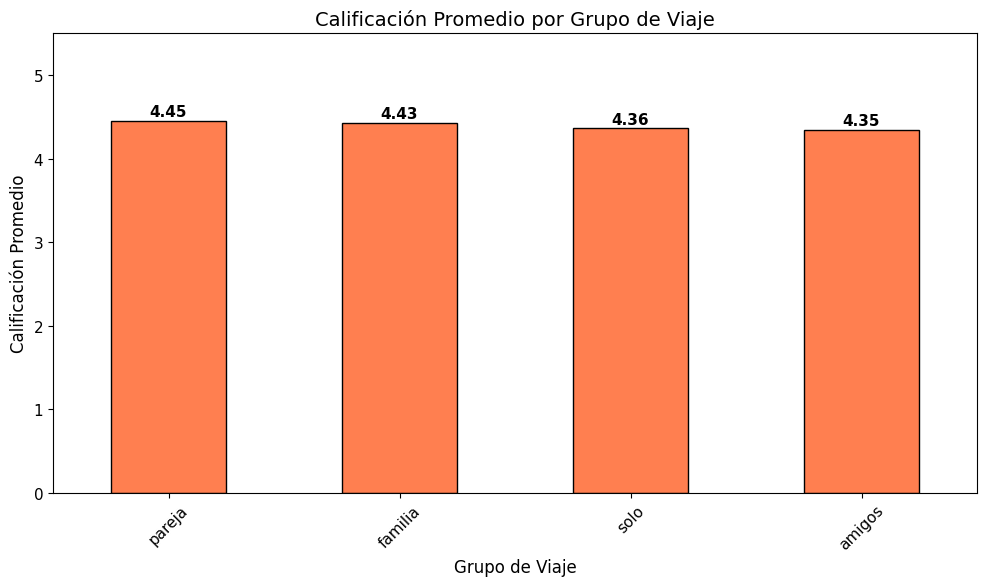

In [47]:
# Análisis por grupo de viaje

print("Distribución de grupos de viaje:")
print(df['grupo_de_viaje'].value_counts())

# Calificación promedio por grupo
grupo_stats = df.groupby('grupo_de_viaje')['calificación'].agg(['mean', 'count']).round(2)
grupo_stats.columns = ['Promedio', 'Conteo']
grupo_stats = grupo_stats.sort_values('Promedio', ascending=False)
print("\nCalificación promedio por grupo de viaje:")
print(grupo_stats)

# Gráfico
plt.figure(figsize=(10, 6))
grupo_means = df.groupby('grupo_de_viaje')['calificación'].mean().sort_values(ascending=False)
grupo_means.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Calificación Promedio por Grupo de Viaje', fontsize=14)
plt.xlabel('Grupo de Viaje', fontsize=12)
plt.ylabel('Calificación Promedio', fontsize=12)
plt.ylim(0, 5.5)
plt.xticks(rotation=45)
for i, v in enumerate(grupo_means.values):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Distribución de sentimiento:
sentimiento
Positivo    669
Negativo     74
Neutral      44
Name: count, dtype: int64


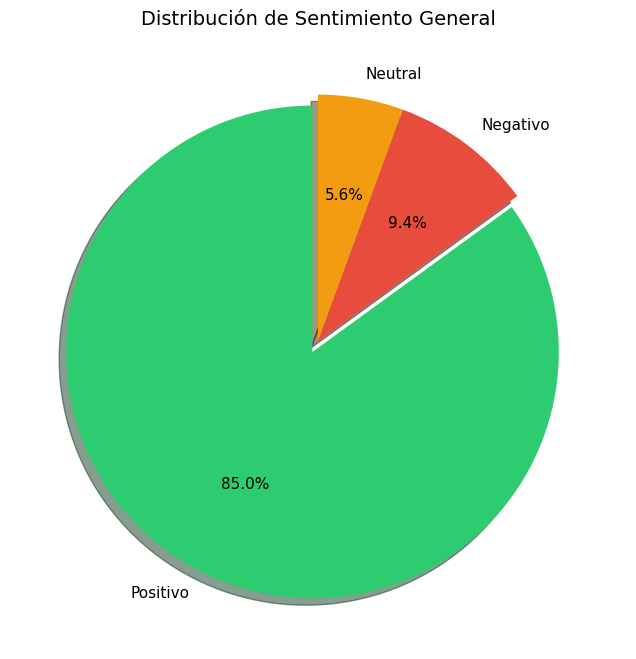


Sentimiento por tipo de lugar (%):
sentimiento      Negativo  Neutral  Positivo
tipo_lugar                                  
hotel                 7.3      4.9      87.8
parque nacional       3.8      4.9      91.3
restaurante          18.1      7.1      74.8


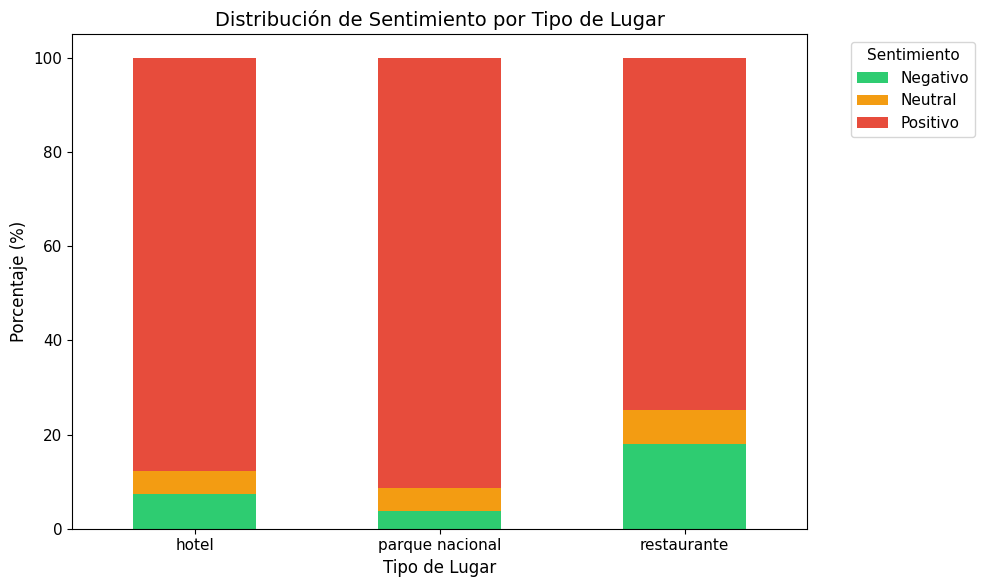

In [48]:
# Análisis de sentimiento

print("Distribución de sentimiento:")
print(df['sentimiento'].value_counts())

# Gráfico de pastel
fig, ax = plt.subplots(figsize=(8, 8))
colores_sentimiento = {'Positivo': '#2ecc71', 'Neutral': '#f39c12', 'Negativo': '#e74c3c'}
sentimiento_counts = df['sentimiento'].value_counts()
ax.pie(sentimiento_counts.values, labels=sentimiento_counts.index, autopct='%1.1f%%',
       colors=[colores_sentimiento[s] for s in sentimiento_counts.index], startangle=90,
       explode=(0.05, 0, 0), shadow=True)
ax.set_title('Distribución de Sentimiento General', fontsize=14)
plt.show()

# Sentimiento por tipo de lugar
sentimiento_por_tipo = pd.crosstab(df['tipo_lugar'], df['sentimiento'], normalize='index') * 100
print("\nSentimiento por tipo de lugar (%):")
print(sentimiento_por_tipo.round(1))

# Gráfico de barras apiladas
sentimiento_por_tipo.plot(kind='bar', stacked=True, figsize=(10, 6),
                          color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Distribución de Sentimiento por Tipo de Lugar', fontsize=14)
plt.xlabel('Tipo de Lugar', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='Sentimiento', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

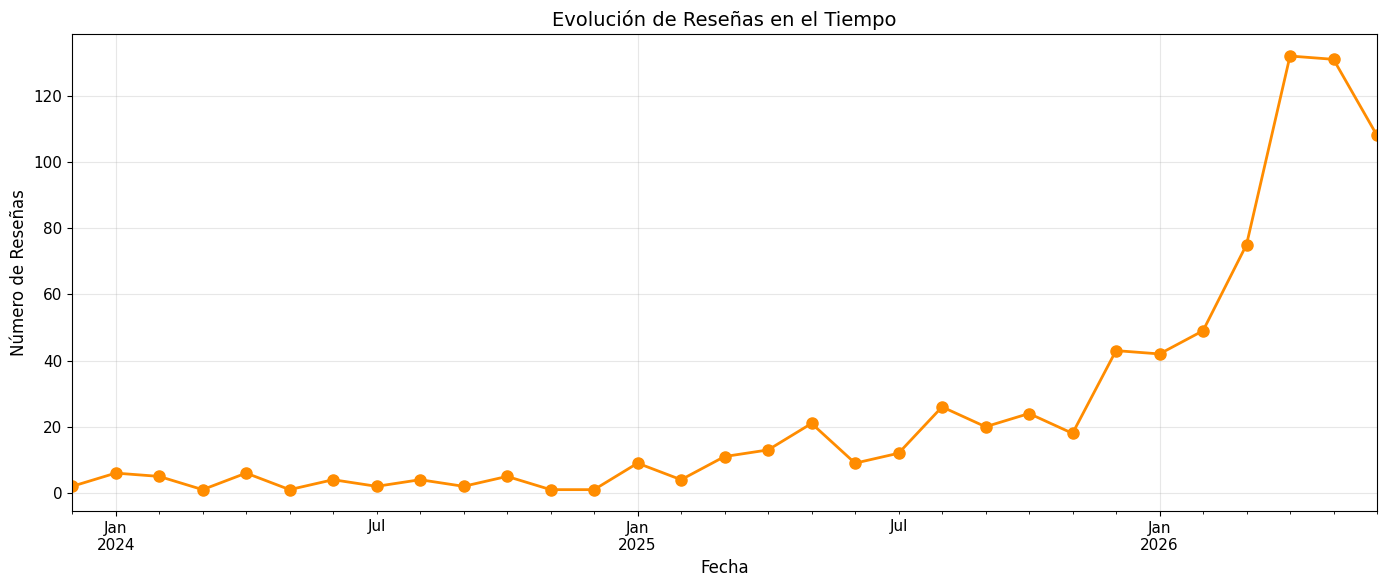

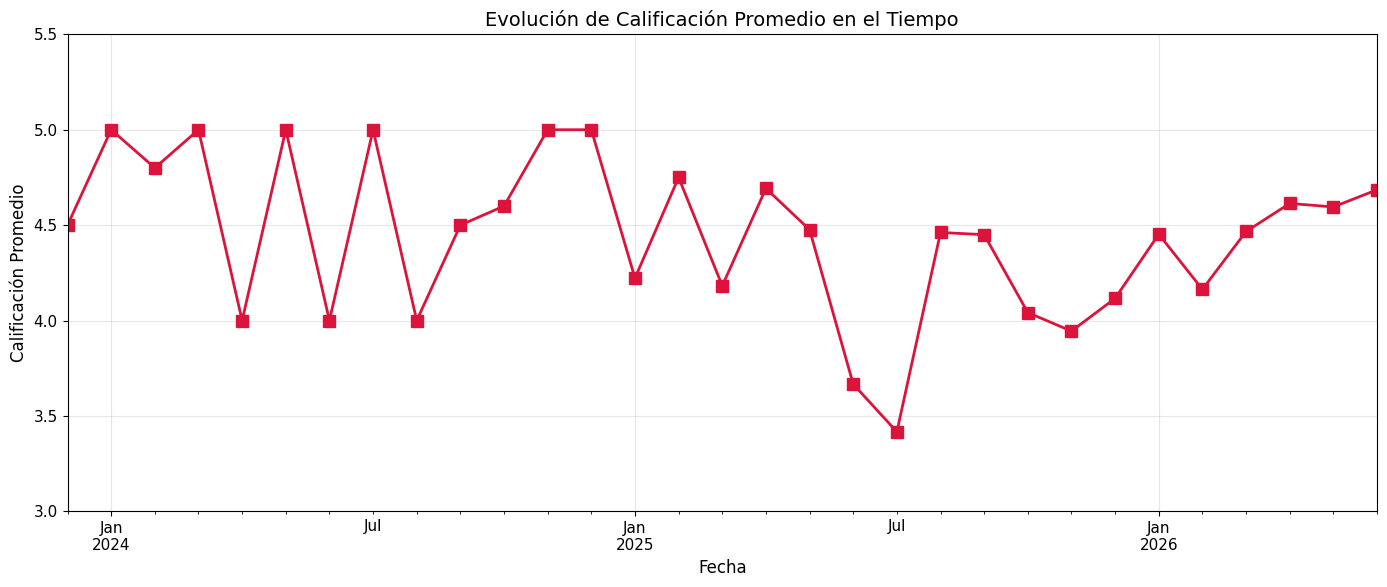

In [49]:
# Análisis temporal

# Filtrar fechas válidas
df_fechas = df.dropna(subset=['fecha']).copy()

if len(df_fechas) > 0:
    # Reseñas por mes
    reseñas_por_mes = df_fechas.groupby(df_fechas['fecha'].dt.to_period('M')).size()

    if len(reseñas_por_mes) > 0:
        plt.figure(figsize=(14, 6))
        reseñas_por_mes.plot(kind='line', marker='o', color='darkorange', linewidth=2, markersize=8)
        plt.title('Evolución de Reseñas en el Tiempo', fontsize=14)
        plt.xlabel('Fecha', fontsize=12)
        plt.ylabel('Número de Reseñas', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Calificación promedio por mes
        promedio_por_mes = df_fechas.groupby(df_fechas['fecha'].dt.to_period('M'))['calificación'].mean()

        plt.figure(figsize=(14, 6))
        promedio_por_mes.plot(kind='line', marker='s', color='crimson', linewidth=2, markersize=8)
        plt.title('Evolución de Calificación Promedio en el Tiempo', fontsize=14)
        plt.xlabel('Fecha', fontsize=12)
        plt.ylabel('Calificación Promedio', fontsize=12)
        plt.ylim(3, 5.5)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("⚠No hay fechas válidas para análisis temporal")